# Análise de Compras Públicas com Python

Este projeto tem como objetivo realizar uma análise exploratória de dados de compras públicas, utilizando bases de licitações e contratos extraídas do Portal da Transparência da Prefeitura de Coronel Fabriciano dos anos de 2024 e 2025.

A análise contempla limpeza, tratamento e exploração dos dados, buscando identificar:

- Volume de processos licitatórios por ano;
- Modalidades mais utilizadas;
- Situação dos processos;
- Valor total contratado;
- Fornecedores com maior valor contratado;
- Categorias mais frequentes dos objetos;
- Evolução temporal das contratações.

Ferramentas utilizadas:
- Python
- Pandas
- Matplotlib
- Seaborn
- Google Colab

In [ ]:
#Importação das bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 150)

sns.set_theme(style="whitegrid")

In [ ]:
#Download dos arquivos

from google.colab import files

uploaded = files.upload()

arquivo_licitacoes = [nome for nome in uploaded.keys() if 'licit' in nome.lower()][0]
arquivo_contratos = [nome for nome in uploaded.keys() if 'contrat' in nome.lower()][0]

print("Arquivo de licitações:", arquivo_licitacoes)
print("Arquivo de contratos:", arquivo_contratos)

Saving contratos.csv to contratos.csv
Saving licitacoes.csv to licitacoes.csv
Arquivo de licitações: licitacoes.csv
Arquivo de contratos: contratos.csv


In [ ]:
#Leitura dos arquivos importados

licitacoes_raw = pd.read_csv(arquivo_licitacoes, header=None, dtype=str)
contratos_raw = pd.read_csv(arquivo_contratos, header=None, dtype=str)

display(licitacoes_raw.head(15))
display(contratos_raw.head(15))

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,NaN,NaN,NaN,NaN,NaN,NaN,18-06-2026 18:43:20,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,PREFEITURA MUNICIPAL DE CORONEL FABRICIANO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,ESTADO DE MINAS GERAIS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,Lista de Processos Licitatórios,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Processo,Modalidade,NaN,NaN,Nro. Modalidade,Abertura,NaN,NaN,NaN,Situação,Objeto,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Publicação,NaN,NaN,NaN,NaN
7,61/2026,CONCORRÊNCIA,NaN,NaN,8,30-06-2026 13:00 <br> 30-,NaN,NaN,11-06-2026,Publicado,"Contratação de empresa, por menor preço global e sob regime de empreitada global, com medições unitárias, com fornecimento de mão de obra, materia...",NaN,NaN
8,63/2026,PREGÃO ELETRÔNICO,NaN,NaN,29,29-06-2026 13:00 <br> 29-,NaN,NaN,12-06-2026,Publicado,"Aquisição de Tomógrafo, para atender ao Centro de Especialidades Médicas – CEM, conforme Convênio nº 1321001817/2025, celebrado entre o Estado de ...",NaN,NaN
9,62/2026,PREGÃO ELETRÔNICO,NaN,NaN,33,26-06-2026 13:00 <br> 26-,NaN,NaN,15-06-2026,Publicado,"Aquisição de materiais esportivos para utilização em atendimento aos usuários do “Programa Mexa-se: Hábitos de Vida Saudável”, em atendimento à Se...",NaN,NaN


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,NaN,NaN,NaN,NaN,NaN,18-06-2026 18:44:43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,PREFEITURA MUNICIPAL DE CORONEL FABRICIANO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,ESTADO DE MINAS GERAIS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,Contratos,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Contrato,Vigência,NaN,NaN,Fornecedor,NaN,Modalidade,NaN,NaN,NaN,NaN,Valor Inicial,Objeto,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Processo,NaN,NaN,NaN,NaN,NaN
7,123/2026,15/03/2027,NaN,NaN,ACACIA CASA E JARDIM LTDA [10.278.338/0001-63],NaN,04 - CONCORRÊNCIA,NaN,79/2026,NaN,"486229,57",NaN,"Contratação de empresa, por menor preço global e sob regime de empreitada global, com medições unitárias, com fornecimento de mão-de-obra, materia...",NaN,NaN
8,122/2026,14/06/2031,NaN,NaN,MAGESTY SERVICOS ODONTOLOGICOS LTDA [66.931.583,NaN,09 - INEXIGIBILIDADE,NaN,26/2026,NaN,"84000,00",NaN,"Credenciamento de pessoas jurídicas especializadas para a prestação de serviços de bucomaxilofacial, consultas, procedimentos e cirurgias de urgên...",NaN,NaN
9,121/2026,14/06/2031,NaN,NaN,CLINICA ODONTOLOGICA VIVANT BLANC LTDA [21.170.096,NaN,09 - INEXIGIBILIDADE,NaN,26/2026,NaN,"84000,00",NaN,"Credenciamento de pessoas jurídicas especializadas para a prestação de serviços de bucomaxilofacial, consultas, procedimentos e cirurgias de urgên...",NaN,NaN


## Observação inicial dos dados

Ao visualizar os arquivos brutos, foi possível perceber que as bases apresentam características comuns em relatórios extraídos de portais públicos, como:

- Cabeçalhos institucionais;
- Linhas vazias;
- Cabeçalhos de tabela repetidos;
- Informações distribuídas em colunas sem nomes adequados;
- Campos com datas e valores em formato textual;
- Objetos de contratação com textos extensos.

Por isso, foi necessário criar uma etapa de limpeza automatizada antes da análise.

In [ ]:
#Limpeza da base de licitações

def limpar_texto(valor):
    if pd.isna(valor):
        return None

    texto = str(valor).strip()

    if texto == "" or texto.lower() in ["nan", "none", "nat"]:
        return None

    return texto


def limpar_licitacoes(caminho):
    df_raw = pd.read_csv(caminho, header=None, dtype=str)

    registros = []

    for _, row in df_raw.iterrows():
        processo = limpar_texto(row.get(0))

        if processo and re.match(r'^\d+/\d{4}$', processo):

            # O CSV tem dois layouts diferentes.
            # Layout expandido: objeto na coluna 10.
            # Layout compacto: objeto na coluna 7.
            if limpar_texto(row.get(10)) is not None or limpar_texto(row.get(8)) is not None:
                numero_col = 4
                abertura_col = 5
                publicacao_col = 8
                situacao_col = 9
                objeto_col = 10
            else:
                numero_col = 2
                abertura_col = 3
                publicacao_col = 5
                situacao_col = 6
                objeto_col = 7

            registros.append({
                'processo': processo,
                'modalidade': limpar_texto(row.get(1)),
                'numero_modalidade': limpar_texto(row.get(numero_col)),
                'data_abertura': limpar_texto(row.get(abertura_col)),
                'data_publicacao': limpar_texto(row.get(publicacao_col)),
                'situacao': limpar_texto(row.get(situacao_col)),
                'objeto': limpar_texto(row.get(objeto_col))
            })

    df = pd.DataFrame(registros)

    df['modalidade'] = df['modalidade'].str.upper().str.strip()
    df['situacao'] = df['situacao'].str.upper().str.strip()

    df['objeto'] = (
        df['objeto']
        .fillna('')
        .str.replace('\t', ' ', regex=False)
        .str.replace('<br>', ' ', regex=False)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

    df.loc[df['objeto'].eq(''), 'objeto'] = pd.NA

    df['ano'] = pd.to_numeric(
        df['processo'].str.extract(r'/(\d{4})')[0],
        errors='coerce'
    )

    abertura_limpa = df['data_abertura'].fillna('').str.replace('/', '-', regex=False)

    df['data_abertura_limpa'] = pd.to_datetime(
        abertura_limpa.str.extract(r'(\d{2}-\d{2}-\d{4})')[0],
        errors='coerce',
        dayfirst=True
    )

    df['data_publicacao'] = pd.to_datetime(
        df['data_publicacao'],
        errors='coerce',
        dayfirst=True
    )

    df['mes_publicacao'] = df['data_publicacao'].dt.month
    df['ano_mes_publicacao'] = df['data_publicacao'].dt.to_period('M').astype(str)

    return df

In [ ]:
#Visualização

licitacoes = limpar_licitacoes('licitacoes.csv')

licitacoes[['processo', 'modalidade', 'situacao', 'objeto']].head()

,processo,modalidade,situacao,objeto
0,61/2026,CONCORRÊNCIA,PUBLICADO,"Contratação de empresa, por menor preço global e sob regime de empreitada global, com medições unitárias, com fornecimento de mão de obra, materia..."
1,63/2026,PREGÃO ELETRÔNICO,PUBLICADO,"Aquisição de Tomógrafo, para atender ao Centro de Especialidades Médicas – CEM, conforme Convênio nº 1321001817/2025, celebrado entre o Estado de ..."
2,62/2026,PREGÃO ELETRÔNICO,PUBLICADO,"Aquisição de materiais esportivos para utilização em atendimento aos usuários do “Programa Mexa-se: Hábitos de Vida Saudável”, em atendimento à Se..."
3,57/2026,CONCORRÊNCIA,PUBLICADO,"Contratação de empresa, por menor preço global e sob regime de empreitada global, com medições unitárias, com fornecimento de mão-de-obra, materia..."
4,47/2026,PREGÃO ELETRÔNICO,PUBLICADO,"Aquisição de veiculos automotores para atender as demandas das Unidades da Secretaria de Governança de Assistência social, tendo como fonte de rec..."


In [ ]:
#Limpeza da base de contratos

def limpar_contratos(caminho):
    df_raw = pd.read_csv(caminho, header=None, dtype=str)

    registros = []

    for _, row in df_raw.iterrows():
        contrato = limpar_texto(row.get(0))

        if contrato and re.match(r'^\d+/\d{4}$', contrato):

            # O CSV de contratos também tem dois layouts.
            # Layout expandido: objeto na coluna 12.
            # Layout compacto: objeto na coluna 9.
            if limpar_texto(row.get(12)) is not None or limpar_texto(row.get(10)) is not None:
                fornecedor_col = 4
                modalidade_col = 6
                processo_col = 8
                valor_col = 10
                objeto_col = 12
            else:
                fornecedor_col = 2
                modalidade_col = 3
                processo_col = 5
                valor_col = 7
                objeto_col = 9

            registros.append({
                'contrato': contrato,
                'vigencia': limpar_texto(row.get(1)),
                'fornecedor': limpar_texto(row.get(fornecedor_col)),
                'modalidade': limpar_texto(row.get(modalidade_col)),
                'processo': limpar_texto(row.get(processo_col)),
                'valor_inicial': limpar_texto(row.get(valor_col)),
                'objeto': limpar_texto(row.get(objeto_col))
            })

    df = pd.DataFrame(registros)

    df['fornecedor'] = df['fornecedor'].str.upper().str.strip()
    df['modalidade'] = df['modalidade'].str.upper().str.strip()

    df['objeto'] = (
        df['objeto']
        .fillna('')
        .str.replace('\t', ' ', regex=False)
        .str.replace('<br>', ' ', regex=False)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )

    df.loc[df['objeto'].eq(''), 'objeto'] = pd.NA

    df['vigencia'] = pd.to_datetime(
        df['vigencia'],
        errors='coerce',
        dayfirst=True
    )

    df['valor_inicial'] = (
        df['valor_inicial']
        .fillna('')
        .str.replace('R$', '', regex=False)
        .str.replace('.', '', regex=False)
        .str.replace(',', '.', regex=False)
        .str.strip()
    )

    df['valor_inicial'] = pd.to_numeric(df['valor_inicial'], errors='coerce')

    df['ano'] = pd.to_numeric(
        df['contrato'].str.extract(r'/(\d{4})')[0],
        errors='coerce'
    )

    df['ano_processo'] = pd.to_numeric(
        df['processo'].str.extract(r'/(\d{4})')[0],
        errors='coerce'
    )

    df['mes_vigencia'] = df['vigencia'].dt.month
    df['ano_mes_vigencia'] = df['vigencia'].dt.to_period('M').astype(str)

    return df

In [ ]:
#Visualização

contratos = limpar_contratos('contratos.csv')

contratos[['contrato', 'fornecedor', 'modalidade', 'valor_inicial', 'objeto']].head()

,contrato,fornecedor,modalidade,valor_inicial,objeto
0,123/2026,ACACIA CASA E JARDIM LTDA [10.278.338/0001-63],04 - CONCORRÊNCIA,486229.57,"Contratação de empresa, por menor preço global e sob regime de empreitada global, com medições unitárias, com fornecimento de mão-de-obra, materia..."
1,122/2026,MAGESTY SERVICOS ODONTOLOGICOS LTDA [66.931.583,09 - INEXIGIBILIDADE,84000.00,"Credenciamento de pessoas jurídicas especializadas para a prestação de serviços de bucomaxilofacial, consultas, procedimentos e cirurgias de urgên..."
2,121/2026,CLINICA ODONTOLOGICA VIVANT BLANC LTDA [21.170.096,09 - INEXIGIBILIDADE,84000.00,"Credenciamento de pessoas jurídicas especializadas para a prestação de serviços de bucomaxilofacial, consultas, procedimentos e cirurgias de urgên..."
3,120/2026,MG REIS LTDA [66.763.968/0001-88],09 - INEXIGIBILIDADE,134400.00,"Credenciamento para prestação de serviços técnicos profissionais especializados, na área de odontologia, para atendimento ao centro de especialida..."
4,119/2026,MAGESTY SERVICOS ODONTOLOGICOS LTDA [66.931.583,09 - INEXIGIBILIDADE,67200.00,"Credenciamento para prestação de serviços técnicos profissionais especializados, na área de odontologia, para atendimento ao centro de especialida..."


In [ ]:
licitacoes = limpar_licitacoes(arquivo_licitacoes)
contratos = limpar_contratos(arquivo_contratos)

In [ ]:
licitacoes[['processo', 'objeto']].head(10)


,processo,objeto
0,61/2026,"Contratação de empresa, por menor preço global e sob regime de empreitada global, com medições unitárias, com fornecimento de mão de obra, materia..."
1,63/2026,"Aquisição de Tomógrafo, para atender ao Centro de Especialidades Médicas – CEM, conforme Convênio nº 1321001817/2025, celebrado entre o Estado de ..."
2,62/2026,"Aquisição de materiais esportivos para utilização em atendimento aos usuários do “Programa Mexa-se: Hábitos de Vida Saudável”, em atendimento à Se..."
3,57/2026,"Contratação de empresa, por menor preço global e sob regime de empreitada global, com medições unitárias, com fornecimento de mão-de-obra, materia..."
4,47/2026,"Aquisição de veiculos automotores para atender as demandas das Unidades da Secretaria de Governança de Assistência social, tendo como fonte de rec..."
5,54/2026,"Registro de Preços, para futura e eventual aquisição de materiais de limpeza e produtos de uso hospitalar, fracassados e desertos no Pregão Eletrô..."
6,44/2026,"Contratação de empresa, por menor preço global e sob regime de empreitada global, com medições unitárias, com fornecimento de mão-de-obra, materia..."
7,60/2026,"Contratação da empresa NEUROBRINQ INDÚSTRIA E COMÉRCIO DE EQUIPAMENTOS ELÉTRICOS LTDA, para implantação, estruturação de salas multissensoriais e ..."
8,59/2026,"Contratação da empresa FAMA EVENTOS LTDA, representante exclusiva da Banda M JACK, para apresentação de show artístico musical no 3º Festival de I..."
9,58/2026,"Contratação da empresa 42.734.151 SIDNEY SILVEIRA SANTOS, representante exclusiva da Banda GERTRUDES, para apresentação de show artístico musical ..."


In [ ]:
print("Antes da limpeza:")
print(f"Linhas no arquivo bruto de licitações: {licitacoes_raw.shape[0]}")
print(f"Linhas no arquivo bruto de contratos: {contratos_raw.shape[0]}")

print("\nDepois da limpeza:")
print(f"Registros válidos de licitações: {licitacoes.shape[0]}")
print(f"Registros válidos de contratos: {contratos.shape[0]}")

Antes da limpeza:
Linhas no arquivo bruto de licitações: 426
Linhas no arquivo bruto de contratos: 444

Depois da limpeza:
Registros válidos de licitações: 300
Registros válidos de contratos: 300


## Resultado da limpeza

Após a aplicação das funções de tratamento, foram mantidas apenas as linhas válidas referentes a processos licitatórios e contratos.

As linhas institucionais, cabeçalhos repetidos, campos vazios e informações sem estrutura tabular foram removidas automaticamente, permitindo a continuidade da análise com dados organizados.

In [ ]:
licitacoes_analise = licitacoes[licitacoes['ano'].isin([2024, 2025])].copy()
contratos_analise = contratos[contratos['ano'].isin([2024, 2025])].copy()

print("Licitações 2024-2025:", licitacoes_analise.shape)
print("Contratos 2024-2025:", contratos_analise.shape)

#A análise considera o ano constante no número do processo/contrato, por representar o exercício administrativo de origem do registro.

Licitações 2024-2025: (238, 11)
Contratos 2024-2025: (178, 11)


In [ ]:
licitacoes_analise.info()

contratos_analise.info()

<class 'pandas.core.frame.DataFrame'>
Index: 238 entries, 18 to 299
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   processo             238 non-null    object        
 1   modalidade           238 non-null    object        
 2   numero_modalidade    238 non-null    object        
 3   data_abertura        238 non-null    object        
 4   data_publicacao      238 non-null    datetime64[ns]
 5   situacao             238 non-null    object        
 6   objeto               238 non-null    object        
 7   ano                  238 non-null    int64         
 8   data_abertura_limpa  238 non-null    datetime64[ns]
 9   mes_publicacao       238 non-null    int32         
 10  ano_mes_publicacao   238 non-null    object        
dtypes: datetime64[ns](2), int32(1), int64(1), object(7)
memory usage: 21.4+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 178 entries, 122 to 299
Data colu

In [ ]:
print("Nulos em licitações:")
display(licitacoes_analise.isnull().sum())

print("Nulos em contratos:")
display(contratos_analise.isnull().sum())

Nulos em licitações:


,0
processo,0
modalidade,0
numero_modalidade,0
data_abertura,0
data_publicacao,0
situacao,0
objeto,0
ano,0
data_abertura_limpa,0
mes_publicacao,0


Nulos em contratos:


,0
contrato,0
vigencia,0
fornecedor,0
modalidade,0
processo,0
valor_inicial,0
objeto,0
ano,0
ano_processo,0
mes_vigencia,0


In [ ]:
print("Licitações duplicadas:", licitacoes_analise.duplicated().sum())
print("Contratos duplicados:", contratos_analise.duplicated().sum())

Licitações duplicadas: 0
Contratos duplicados: 0


In [ ]:
#Cria categorias a partir do objeto

import unicodedata

def normalizar_texto(texto):
    texto = str(texto).lower()
    texto = unicodedata.normalize('NFKD', texto)
    texto = ''.join([c for c in texto if not unicodedata.combining(c)])
    return texto


def classificar_categoria(objeto):
    texto = normalizar_texto(objeto)

    if any(p in texto for p in [
        'generos alimenticios', 'alimentacao', 'refeicao', 'lanche',
        'coffee break', 'cesta', 'paes', 'pao', 'hortifrutigranjeiros',
        'carne', 'frios', 'leite'
    ]):
        return 'Alimentação'

    elif any(p in texto for p in [
        'obra', 'pavimentacao', 'recapeamento', 'ponte', 'reforma',
        'engenharia', 'terraplanagem', 'demolicao', 'construcao',
        'empreitada', 'drenagem'
    ]):
        return 'Obras e Engenharia'

    elif any(p in texto for p in [
        'veiculo', 'veiculos', 'automotor', 'transporte', 'onibus',
        'combustivel', 'manutencao veicular', 'pneu'
    ]):
        return 'Veículos e Transporte'

    elif any(p in texto for p in [
        'software', 'sistema', 'tecnologia', 'informatica', 'computador',
        'notebook', 'licenca', 'internet', 'impressora'
    ]):
        return 'Tecnologia'

    elif any(p in texto for p in [
        'limpeza', 'higiene', 'descartavel', 'copa', 'cozinha',
        'material de consumo', 'utensilio', 'expediente'
    ]):
        return 'Materiais de Consumo'

    elif any(p in texto for p in [
        'show', 'evento', 'festival', 'cultura', 'artistico',
        'sonorizacao', 'palco'
    ]):
        return 'Eventos e Cultura'

    elif any(p in texto for p in [
        'medicamento', 'hospital', 'upa', 'ubs', 'sus', 'odontolog',
        'medico', 'medica', 'exame', 'tomografo', 'clinica',
        'fralda', 'consulta', 'cirurgia', 'bucomaxilofacial',
        'material medico'
    ]):
        return 'Saúde'

    elif any(p in texto for p in [
        'escola', 'educacao', 'aluno', 'cmei', 'creche',
        'uniforme', 'material escolar', 'professor'
    ]):
        return 'Educação'

    elif any(p in texto for p in [
        'correios', 'postais', 'jornal', 'publicacao', 'publicidade',
        'atos administrativos', 'diario oficial'
    ]):
       return 'Comunicação e Publicações'

    elif any(p in texto for p in [
        'locacao de imovel', 'imobiliaria', 'aluguel', 'imovel'
    ]):
       return 'Locação de Imóveis'

    elif any(p in texto for p in [
        'consultoria', 'assessoria', 'juridica', 'servicos tecnicos',
        'servico tecnico', 'bancarios', 'instituicoes financeiras'
    ]):
        return 'Serviços Técnicos e Administrativos'

    elif any(p in texto for p in [
        'brinquedos', 'material esportivo', 'camisas', 'materiais permanentes',
        'mobiliario', 'geladeira', 'freezer', 'elevador'
    ]):
        return 'Materiais e Equipamentos'

    else:
        return 'Outros'

In [ ]:
licitacoes_analise['categoria'] = licitacoes_analise['objeto'].apply(classificar_categoria)
contratos_analise['categoria'] = contratos_analise['objeto'].apply(classificar_categoria)


In [ ]:
licitacoes_analise[['processo', 'objeto', 'categoria']].head()

,processo,objeto,categoria
18,237/2025,O objeto da presente licitação é selecionar a melhor proposta para exploração e prestação do serviço público de transporte coletivo urbano de pass...,Obras e Engenharia
44,240/2025,Concessão de apoio da Administração Pública Municipal para a execução de atividades de implantação e desenvolvimento de iniciação instrumental e m...,Eventos e Cultura
60,239/2025,"Aquisição de gêneros alimentícios do tipo hortifrutigranjeiros, em atendimento à Secretaria de Governança de Assistência Social; Secretaria de Gov...",Alimentação
64,233/2025,"Aquisição de veículo automotor tipo picape, para atender ao plano de trabalho do Município de Coronel Fabriciano, aprovado em resposta ao “Acordo ...",Veículos e Transporte
65,230/2025,Futura e eventual aquisição de Pães para assegurar a continuidade de fornecimento nas unidades do Sistema Único de Assistência Social - SUAS sob g...,Alimentação


In [ ]:
contratos_analise[['contrato', 'objeto', 'categoria']].head()

,contrato,objeto,categoria
122,292/2025,"Contratação da EMPRESA BRASILEIRA DE CORREIOS E TELÉGRAFOS, para prestação de serviços postais das Autuações de Trânsito e Notificações de Penalid...",Comunicação e Publicações
123,290/2025,"Credenciamento de pessoa jurídica para fornecer serviços de consultas médicas, no território de Coronel Fabriciano, em conformidade com a “Tabela ...",Tecnologia
124,289/2025,"Credenciamento de pessoa jurídica para fornecer serviços de consultas médicas, no território de Coronel Fabriciano, em conformidade com a “Tabela ...",Tecnologia
125,288/2025,"Credenciamento de pessoa jurídica para fornecer serviços de Consultas Médicas, no território de Coronel Fabriciano, com valores diferenciados apro...",Saúde
126,287/2025,"Credenciamento de pessoa jurídica para fornecer serviços de Consultas Médicas, no território de Coronel Fabriciano, com valores diferenciados apro...",Saúde


In [ ]:
#Indicadores Gerais

total_licitacoes = licitacoes_analise.shape[0]
total_contratos = contratos_analise.shape[0]
valor_total_contratos = contratos_analise['valor_inicial'].sum()

valor_total_por_processo = (
    contratos_analise
    .drop_duplicates(subset=['processo', 'valor_inicial'])
    ['valor_inicial']
    .sum()
)

valor_medio_contrato = contratos_analise['valor_inicial'].mean()
maior_contrato = contratos_analise['valor_inicial'].max()

print(f"Total de licitações: {total_licitacoes}")
print(f"Total de contratos: {total_contratos}")
print("Valor total considerando todos os contratos:", formatar_moeda(valor_total_contratos))
print("Valor estimado considerando processos únicos:", formatar_moeda(valor_total_por_processo))
print(f"Valor médio dos contratos: R$ {valor_medio_contrato:,.2f}")
print(f"Maior contrato: R$ {maior_contrato:,.2f}")

Total de licitações: 238
Total de contratos: 178
Valor total considerando todos os contratos: R$ 186.381.312,74
Valor estimado considerando processos únicos: R$ 89.706.558,84
Valor médio dos contratos: R$ 1,047,086.03
Maior contrato: R$ 14,898,928.00


In [ ]:
licitacoes_por_ano = (
    licitacoes_analise
    .groupby('ano')['processo']
    .count()
    .reset_index()
    .rename(columns={'processo': 'quantidade'})
)

licitacoes_por_ano

,ano,quantidade
0,2024,5
1,2025,233


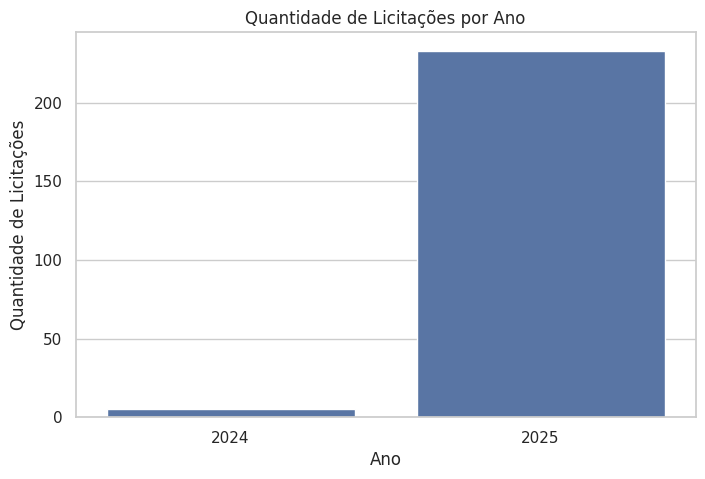

In [ ]:
#Quantidade de Licitações por ano

plt.figure(figsize=(8,5))
sns.barplot(data=licitacoes_por_ano, x='ano', y='quantidade')
plt.title('Quantidade de Licitações por Ano')
plt.xlabel('Ano')
plt.ylabel('Quantidade de Licitações')
plt.savefig('licitacoes_por_ano.png', dpi=300, bbox_inches='tight')
plt.show()

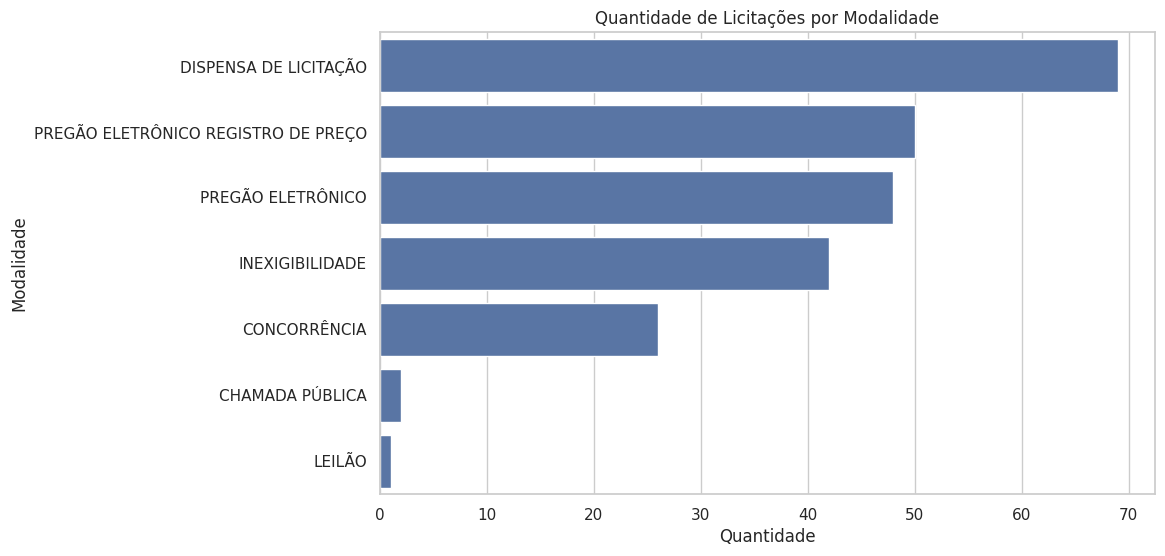

In [ ]:
#Quantidade de licitações por modalidade

licitacoes_modalidade = (
    licitacoes_analise['modalidade']
    .value_counts()
    .reset_index()
)

licitacoes_modalidade.columns = ['modalidade', 'quantidade']

licitacoes_modalidade

plt.figure(figsize=(10,6))
sns.barplot(data=licitacoes_modalidade, x='quantidade', y='modalidade')
plt.title('Quantidade de Licitações por Modalidade')
plt.xlabel('Quantidade')
plt.ylabel('Modalidade')
plt.savefig('licitacoes_por_ano.png', dpi=300, bbox_inches='tight')
plt.show()

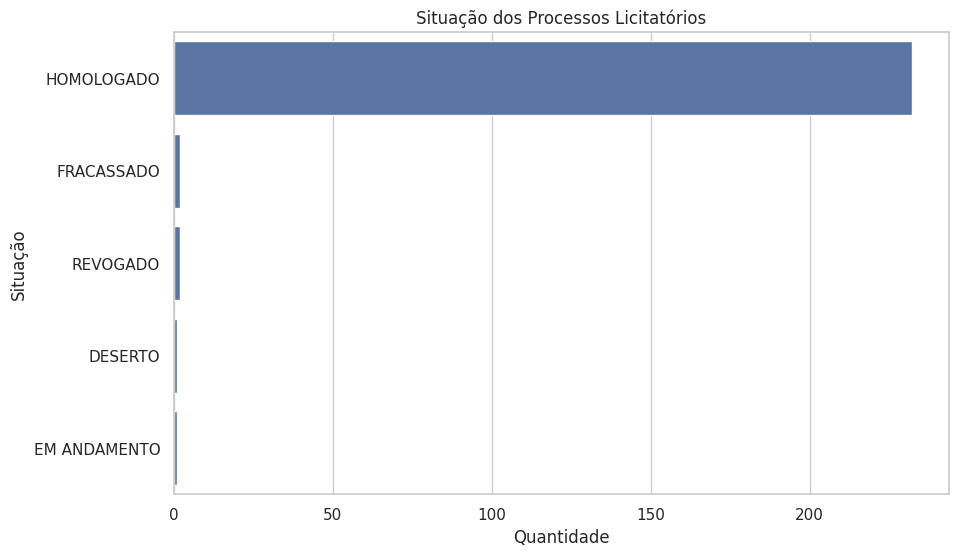

In [ ]:
#Status dos Processos Licitatório

situacao_processos = (
    licitacoes_analise['situacao']
    .value_counts()
    .reset_index()
)

situacao_processos.columns = ['situacao', 'quantidade']

situacao_processos

plt.figure(figsize=(10,6))
sns.barplot(data=situacao_processos, x='quantidade', y='situacao')
plt.title('Situação dos Processos Licitatórios')
plt.xlabel('Quantidade')
plt.ylabel('Situação')
plt.savefig('licitacoes_por_ano.png', dpi=300, bbox_inches='tight')
plt.show()

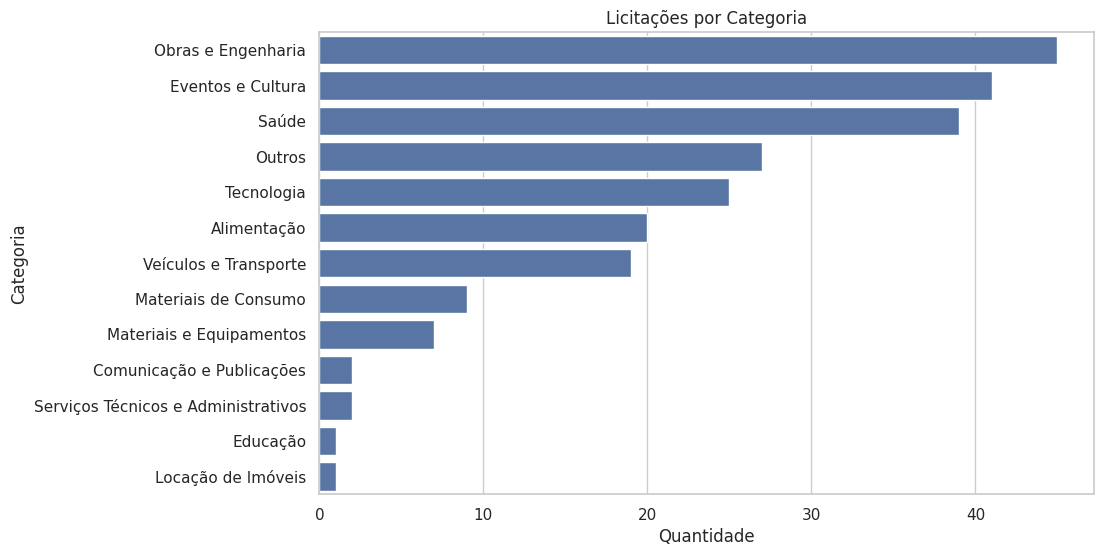

In [ ]:
#Licitações por Categoria

licitacoes_categoria = (
    licitacoes_analise['categoria']
    .value_counts()
    .reset_index()
)

licitacoes_categoria.columns = ['categoria', 'quantidade']

licitacoes_categoria
plt.figure(figsize=(10,6))
sns.barplot(data=licitacoes_categoria, x='quantidade', y='categoria')
plt.title('Licitações por Categoria')
plt.xlabel('Quantidade')
plt.ylabel('Categoria')
plt.savefig('licitacoes_por_ano.png', dpi=300, bbox_inches='tight')
plt.show()

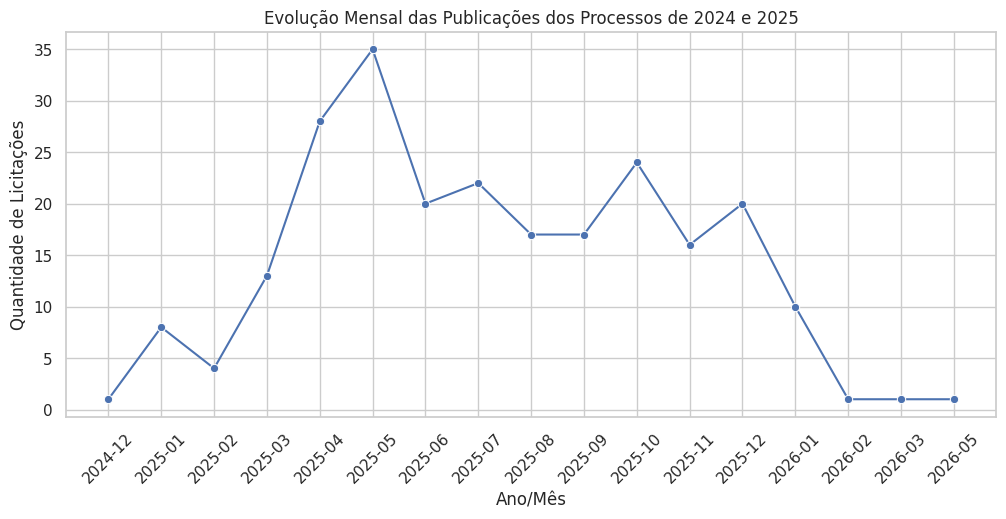

In [ ]:
#Evolução mensal por ano

evolucao_licitacoes = (
    licitacoes_analise
    .dropna(subset=['data_publicacao'])
    .groupby('ano_mes_publicacao')['processo']
    .count()
    .reset_index()
    .rename(columns={'processo': 'quantidade'})
)

evolucao_licitacoes
plt.figure(figsize=(12,5))
sns.lineplot(data=evolucao_licitacoes, x='ano_mes_publicacao', y='quantidade', marker='o')
plt.title('Evolução Mensal das Publicações dos Processos de 2024 e 2025')
plt.xlabel('Ano/Mês')
plt.ylabel('Quantidade de Licitações')
plt.xticks(rotation=45)
plt.savefig('licitacoes_por_ano.png', dpi=300, bbox_inches='tight')
plt.show()

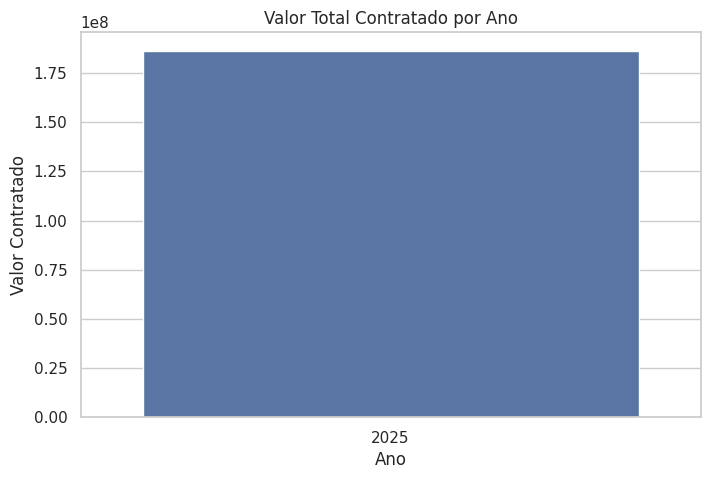

In [ ]:
#Valor contratado por ano

valor_por_ano = (
    contratos_analise
    .groupby('ano')['valor_inicial']
    .sum()
    .reset_index()
)

valor_por_ano
plt.figure(figsize=(8,5))
sns.barplot(data=valor_por_ano, x='ano', y='valor_inicial')
plt.title('Valor Total Contratado por Ano')
plt.xlabel('Ano')
plt.ylabel('Valor Contratado')
plt.savefig('licitacoes_por_ano.png', dpi=300, bbox_inches='tight')
plt.show()

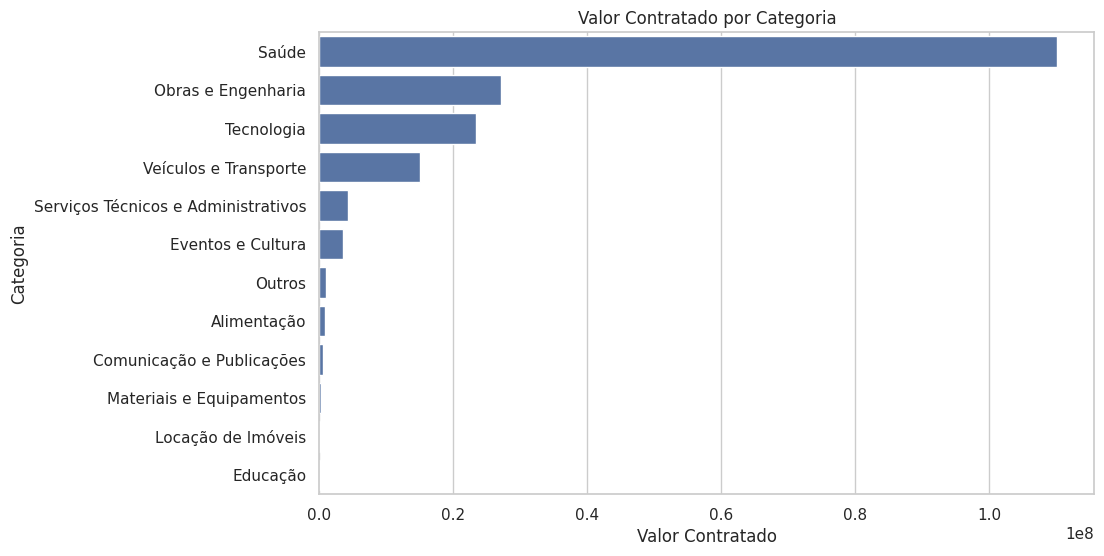

In [ ]:
#Valor contratado por categoria

valor_por_categoria = (
    contratos_analise
    .groupby('categoria')['valor_inicial']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

valor_por_categoria
plt.figure(figsize=(10,6))
sns.barplot(data=valor_por_categoria, x='valor_inicial', y='categoria')
plt.title('Valor Contratado por Categoria')
plt.xlabel('Valor Contratado')
plt.ylabel('Categoria')
plt.savefig('licitacoes_por_ano.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
contratos_analise['fornecedor_limpo'] = (
    contratos_analise['fornecedor']
    .str.replace(r'\s*\[.*$', '', regex=True)
    .str.strip()
)

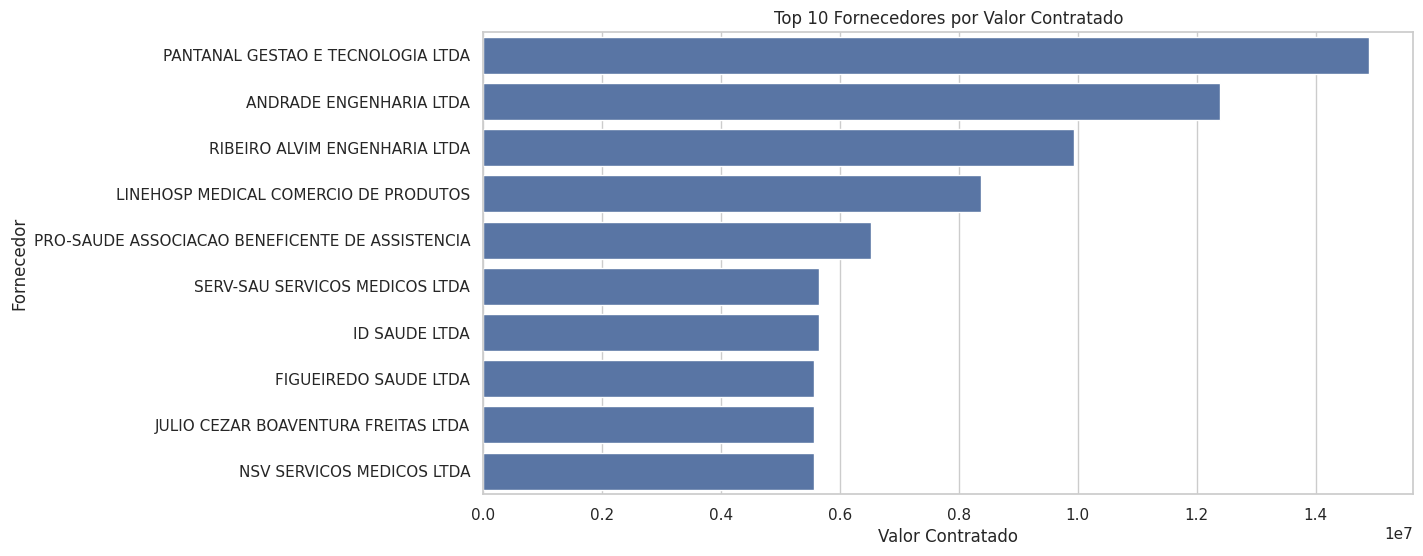

In [ ]:
#Top 10 fornecedores por valor contratado

top_fornecedores = (
    contratos_analise
    .groupby('fornecedor_limpo')['valor_inicial']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)


top_fornecedores
plt.figure(figsize=(12,6))
sns.barplot(data=top_fornecedores, x='valor_inicial', y='fornecedor_limpo')
plt.title('Top 10 Fornecedores por Valor Contratado')
plt.xlabel('Valor Contratado')
plt.ylabel('Fornecedor')
plt.savefig('licitacoes_por_ano.png', dpi=300, bbox_inches='tight')
plt.show()

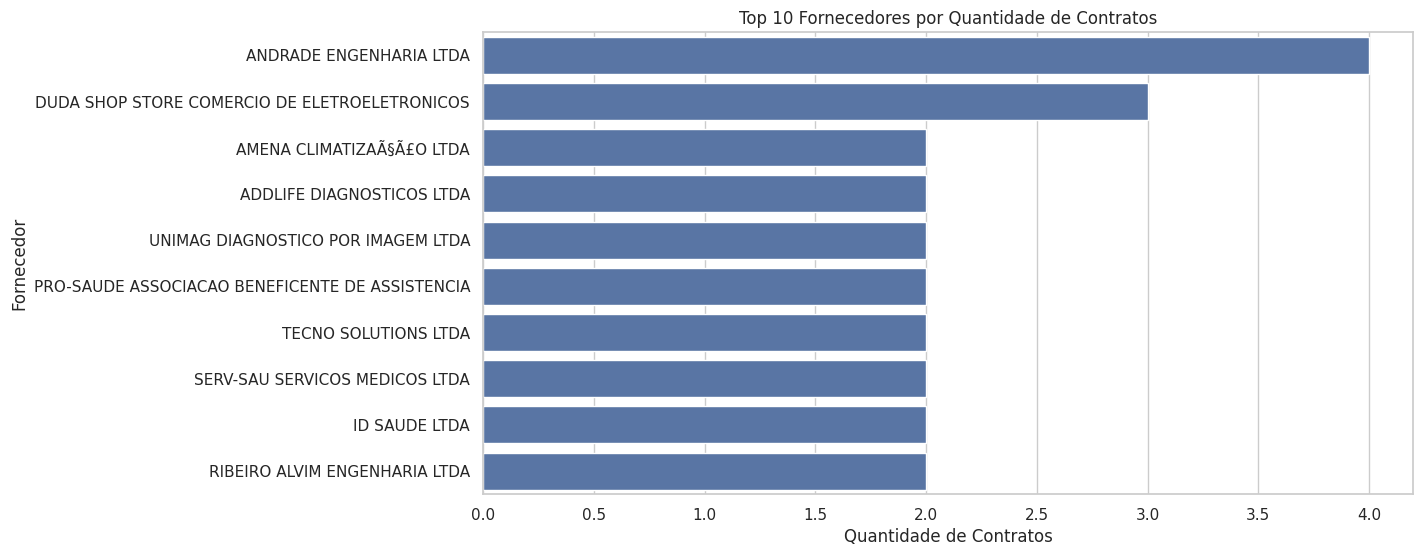

In [ ]:
#Quantidade de contratos por fornecedor

qtd_contratos_fornecedor = (
    contratos_analise
    .groupby('fornecedor_limpo')['contrato']
    .count()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

qtd_contratos_fornecedor.columns = ['fornecedor_limpo', 'quantidade_contratos']

qtd_contratos_fornecedor
plt.figure(figsize=(12,6))
sns.barplot(data=qtd_contratos_fornecedor, x='quantidade_contratos', y='fornecedor_limpo')
plt.title('Top 10 Fornecedores por Quantidade de Contratos')
plt.xlabel('Quantidade de Contratos')
plt.ylabel('Fornecedor')
plt.savefig('licitacoes_por_ano.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
contratos_analise['modalidade_limpa'] = (
    contratos_analise['modalidade']
    .str.replace(r'^\d+\s*-\s*', '', regex=True)
    .str.strip()
)

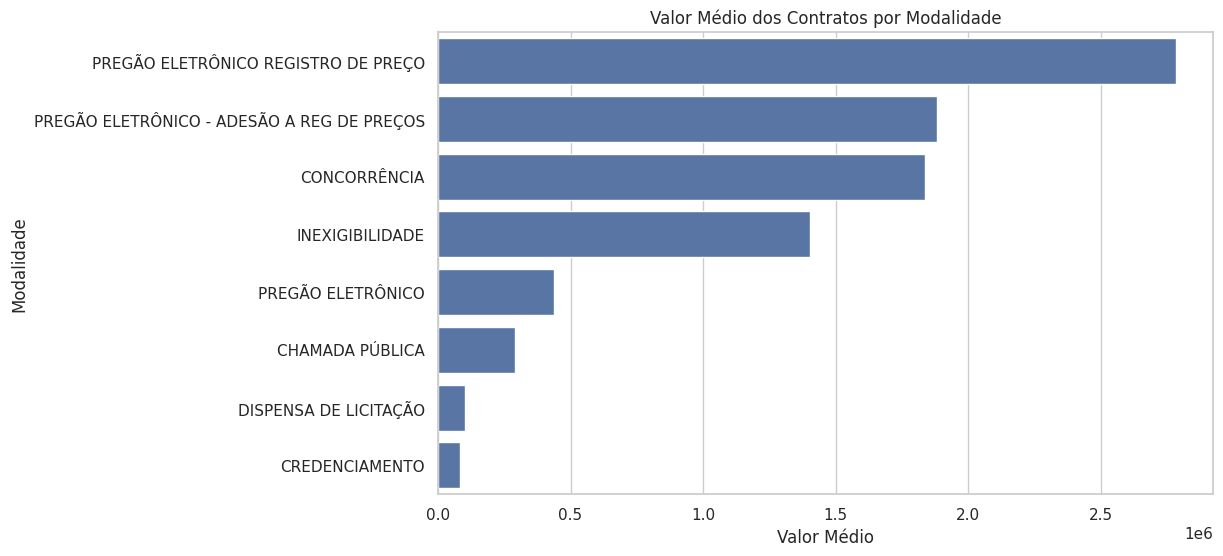

In [ ]:
#Valor médio por modalidade

valor_medio_modalidade = (
    contratos_analise
    .groupby('modalidade_limpa')['valor_inicial']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

valor_medio_modalidade
plt.figure(figsize=(10,6))
sns.barplot(data=valor_medio_modalidade, x='valor_inicial', y='modalidade_limpa')
plt.title('Valor Médio dos Contratos por Modalidade')
plt.xlabel('Valor Médio')
plt.ylabel('Modalidade')
plt.savefig('licitacoes_por_ano.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
base_integrada = contratos_analise.merge(
    licitacoes_analise,
    on='processo',
    how='left',
    suffixes=('_contrato', '_licitacao'),
    indicator=True,
    validate='many_to_one'
)

base_integrada['processo_encontrado'] = base_integrada['_merge'].eq('both')

percentual_integracao = base_integrada['processo_encontrado'].mean() * 100

print(f"Percentual de contratos vinculados a processos licitatórios encontrados: {percentual_integracao:.2f}%")

Percentual de contratos vinculados a processos licitatórios encontrados: 60.11%


In [ ]:
#Contratos sem licitações

contratos_sem_licitacao = base_integrada[base_integrada['_merge'] == 'left_only']

contratos_sem_licitacao[[
    'contrato',
    'processo',
    'fornecedor',
    'modalidade_contrato',
    'valor_inicial',
    'objeto_contrato'
]].head(10)

,contrato,processo,fornecedor,modalidade_contrato,valor_inicial,objeto_contrato
0,292/2025,328/2025,EMPRESA BRASILEIRA DE CORREIOS E TELEGRAFOS,09 - INEXIGIBILIDADE,250000.0,"Contratação da EMPRESA BRASILEIRA DE CORREIOS E TELÉGRAFOS, para prestação de serviços postais das Autuações de Trânsito e Notificações de Penalid..."
3,288/2025,313/2025,CASTRO & MENDES MEDICINA INTEGRADA LTDA [44.935.753,09 - INEXIGIBILIDADE,5568000.0,"Credenciamento de pessoa jurídica para fornecer serviços de Consultas Médicas, no território de Coronel Fabriciano, com valores diferenciados apro..."
4,287/2025,313/2025,RAFAELA CARVALHO SL SERVICOS MEDICOS LTDA.,09 - INEXIGIBILIDADE,5568000.0,"Credenciamento de pessoa jurídica para fornecer serviços de Consultas Médicas, no território de Coronel Fabriciano, com valores diferenciados apro..."
5,286/2025,313/2025,LETÍCIA BISSIATO FEDERICI LTDA [54.555.670/0001-01],09 - INEXIGIBILIDADE,5568000.0,"Credenciamento de pessoa jurídica para fornecer serviços de Consultas Médicas, no território de Coronel Fabriciano, com valores diferenciados apro..."
6,285/2025,313/2025,JULIO CEZAR BOAVENTURA FREITAS LTDA [59.672.542/0001-,09 - INEXIGIBILIDADE,5568000.0,"Credenciamento de pessoa jurídica para fornecer serviços de Consultas Médicas, no território de Coronel Fabriciano, com valores diferenciados apro..."
7,284/2025,313/2025,ID SAUDE LTDA [61.242.817/0001-60],09 - INEXIGIBILIDADE,5568000.0,"Credenciamento de pessoa jurídica para fornecer serviços de Consultas Médicas, no território de Coronel Fabriciano, com valores diferenciados apro..."
8,283/2025,313/2025,TL CARVALHO SERVICOS MEDICOS LTDA [53.344.541/0001-,09 - INEXIGIBILIDADE,5568000.0,"Credenciamento de pessoa jurídica para fornecer serviços de Consultas Médicas, no território de Coronel Fabriciano, com valores diferenciados apro..."
9,282/2025,313/2025,SERV-SAU SERVICOS MEDICOS LTDA [61.922.304/0001-09],09 - INEXIGIBILIDADE,5568000.0,"Credenciamento de pessoa jurídica para fornecer serviços de Consultas Médicas, no território de Coronel Fabriciano, com valores diferenciados apro..."
10,281/2025,313/2025,HEMERSON HUBNER SERVICOS MEDICOS LTDA [45.557.471,09 - INEXIGIBILIDADE,5568000.0,"Credenciamento de pessoa jurídica para fornecer serviços de Consultas Médicas, no território de Coronel Fabriciano, com valores diferenciados apro..."
11,280/2025,313/2025,ALFA GREGHI CONSULTORIA MEDICA LTDA [53.053.564/0001-,09 - INEXIGIBILIDADE,5568000.0,"Credenciamento de pessoa jurídica para fornecer serviços de Consultas Médicas, no território de Coronel Fabriciano, com valores diferenciados apro..."


In [ ]:
base_integrada['processo_encontrado'] = base_integrada['modalidade_licitacao'].notna()

base_integrada['processo_encontrado'].value_counts()

,count
processo_encontrado,
True,107
False,71


In [ ]:
percentual_integracao = base_integrada['processo_encontrado'].mean() * 100

print(f"Percentual de contratos vinculados a processos licitatórios encontrados: {percentual_integracao:.2f}%")

Percentual de contratos vinculados a processos licitatórios encontrados: 60.11%


In [ ]:
base_final = base_integrada[[
    'contrato',
    'processo',
    'fornecedor',
    'modalidade_contrato',
    'valor_inicial',
    'categoria_contrato',
    'ano_contrato',
    'vigencia',
    'situacao',
    'objeto_contrato'
]].copy()

base_final.head()

,contrato,processo,fornecedor,modalidade_contrato,valor_inicial,categoria_contrato,ano_contrato,vigencia,situacao,objeto_contrato
0,292/2025,328/2025,EMPRESA BRASILEIRA DE CORREIOS E TELEGRAFOS,09 - INEXIGIBILIDADE,250000.0,Outros,2025,2027-07-24,NaN,"Contratação da EMPRESA BRASILEIRA DE CORREIOS E TELÉGRAFOS, para prestação de serviços postais das Autuações de Trânsito e Notificações de Penalid..."
1,290/2025,182/2025,PRO-SAUDE ASSOCIACAO BENEFICENTE DE ASSISTENCIA,09 - INEXIGIBILIDADE,3546400.0,Tecnologia,2025,2026-12-29,HOMOLOGADO,"Credenciamento de pessoa jurídica para fornecer serviços de consultas médicas, no território de Coronel Fabriciano, em conformidade com a “Tabela ..."
2,289/2025,182/2025,PRO-SAUDE ASSOCIACAO BENEFICENTE DE ASSISTENCIA,09 - INEXIGIBILIDADE,2970000.0,Tecnologia,2025,2026-12-29,HOMOLOGADO,"Credenciamento de pessoa jurídica para fornecer serviços de consultas médicas, no território de Coronel Fabriciano, em conformidade com a “Tabela ..."
3,288/2025,313/2025,CASTRO & MENDES MEDICINA INTEGRADA LTDA [44.935.753,09 - INEXIGIBILIDADE,5568000.0,Saúde,2025,2027-02-01,NaN,"Credenciamento de pessoa jurídica para fornecer serviços de Consultas Médicas, no território de Coronel Fabriciano, com valores diferenciados apro..."
4,287/2025,313/2025,RAFAELA CARVALHO SL SERVICOS MEDICOS LTDA.,09 - INEXIGIBILIDADE,5568000.0,Saúde,2025,2027-02-01,NaN,"Credenciamento de pessoa jurídica para fornecer serviços de Consultas Médicas, no território de Coronel Fabriciano, com valores diferenciados apro..."


In [ ]:
#Exportar bases tratadas

licitacoes_analise.to_csv('licitacoes_tratadas.csv', index=False, encoding='utf-8-sig')
contratos_analise.to_csv('contratos_tratados.csv', index=False, encoding='utf-8-sig')
base_integrada.to_csv('base_integrada_compras_publicas.csv', index=False, encoding='utf-8-sig')


In [ ]:
files.download('licitacoes_tratadas.csv')
files.download('contratos_tratados.csv')
files.download('base_integrada_compras_publicas.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>